<a href="https://colab.research.google.com/github/ddopazo92/Introduccion_datascience_diego_dopazo/blob/ciencia-de-datos-II/PROYECTO-DOPAZODIEGO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ABSTRACTO:**

Este proyecto realiza un análisis exploratorio de datos (EDA) y **modelado predictivo mediante Machine Learning** sobre el próximo Mundial de Fútbol de 2026. Utilizando un dataset oficial que contiene el calendario, sedes y equipos, se enriquece con estadísticas de rendimiento de los equipos durante 2025 y datos demográficos obtenidos a través de la API de Rest Countries.

**El problema se aborda como un problema de clasificación binaria:** predecir qué equipos clasificarán a octavos de final del torneo, utilizando variables como ranking FIFA, rendimiento ofensivo/defensivo y condición de anfitrión.

Se entrenan y optimizan múltiples modelos de Machine Learning (Regresión Logística, Random Forest y XGBoost) utilizando técnicas de validación cruzada, optimización de hiperparámetros con GridSearchCV, y se evalúa su performance mediante métricas como Accuracy, Precision, Recall, F1-Score y AUC-ROC. Además, se utiliza SHAP para interpretar las predicciones del mejor modelo.

Este análisis está dirigido a aficionados al fútbol interesados en el análisis de datos, científicos de datos y cualquier persona que busque una comprensión más profunda de los factores que podrían influir en el desarrollo del torneo.

# **METADATA**

¿Qué incluye este dataset?

Este conjunto de datos contiene 5 archivos CSV, completamente normalizados y listos para su análisis. Incluye el calendario oficial, información de sedes, datos de los equipos y estadísticas de rendimiento previas al torneo. Este último archivo fue creado por mí con información verídica para enriquecer el análisis.

**FUENTE PRINCIPAL:** [FIFA World Cup 2026 Match Data (Unofficial)](https://www.kaggle.com/datasets/areezvisram12/fifa-world-cup-2026-match-data-unofficial)

1.  **matches.csv / Tabla de partidos**
    El calendario principal que contiene los 104 partidos del Mundial 2026, desde la Fase de Grupos hasta la Final.
    *   `match_number`: Número oficial del partido (1-104).
    *   `kickoff_at`: Fecha y hora (formato ISO 8601 con diferencias UTC).
    *   `home_team_id` / `away_team_id`: Vinculación con la tabla de equipos (`teams.csv`).
    *   `city_id`: Vinculación con la tabla de ciudades sede (`host_cities.csv`).
    *   `stage_id`: Identificador de la fase del torneo (se vincula con `tournament_stages.csv`).
    *   `match_label`: Etiqueta descriptiva del partido (ej. "Group A", "Final").

2.  **host_cities.csv / Tabla de ciudades sede**
    Datos geográficos y de sedes para las 16 ciudades anfitrionas distribuidas en Estados Unidos, México y Canadá.
    *   `id`: Identificador único de la ciudad.
    *   `Ciudad`: Nombre de la ciudad sede.
    *   `Pais`: País anfitrión (USA, Canada, Mexico).
    *   `Estadio`: Nombre oficial del estadio.
    *   `Ubicación`: Región geográfica (Este, Central u Oeste).

3.  **teams.csv / Tabla de equipos**
    Los 48 equipos clasificados para el torneo.
    *   `id`: Identificador único del equipo.
    *   `team_name`: Nombre del equipo.
    *   `fifa_code`: Código FIFA oficial de tres letras.
    *   `group_letter`: El grupo asignado (A-L).
    *   `is_placeholder`: Indica si el equipo es un clasificado directo (False) o un espacio reservado para los ganadores de los playoffs (True).

4.  **tournament_stages.csv / Tabla de fases del torneo**
    *   `id`: Identificador único de la fase.
    *   `stage_name`: El nombre oficial de la fase (ej. "Group Stage", "Final").
    *   `stage_order`: Un valor numérico para asegurar que las fases se muestren en el orden cronológico correcto (1 al 7).

5.  **team_stats_2025.csv / Estadísticas de equipos (ARCHIVO INCORPORADO)**
    Datos de rendimiento de las selecciones durante el año 2025 (partidos amistosos y oficiales), ideales para análisis predictivos.
    *   `id_equipo`: Identificador del equipo (se vincula con `teams.csv`).
    *   `team`: Nombre del equipo.
    *   `ranking_fifa`: Posición en el ranking FIFA (actualización de enero de 2026).
    *   `partidos_jugados_2025`: Total de partidos jugados en 2025.
    *   `ganados_2025`: Partidos ganados en 2025.
    *   `empatados_2025`: Partidos empatados en 2025.
    *   `perdidos_2025`: Partidos perdidos en 2025.
    *   `goles_favor_2025`: Goles marcados en 2025.
    *   `goles_contra_2025`: Goles recibidos en 2025.

# **OBJETIVO ANALÍTICO**

Analizar los datos oficiales y estadísticos del Mundial 2026 para identificar patrones de rendimiento, tendencias competitivas y posibles factores determinantes en los resultados de los partidos. Se evaluará la relación entre las estadísticas históricas de los equipos (incluyendo ranking y datos demográficos), la ventaja de ser país anfitrión, la fase del torneo y la sede del encuentro, culminando con la validación de hipótesis futbolísticas comunes.

# **IMPORTACION DE DATA**

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

# URL raw permanente (sin token)
url_fases = "https://raw.githubusercontent.com/ddopazo92/Introduccion_datascience_diego_dopazo/refs/heads/ciencia-de-datos-II/tournament_stages.csv"
url_equipos = "https://raw.githubusercontent.com/ddopazo92/Introduccion_datascience_diego_dopazo/refs/heads/ciencia-de-datos-II/teams.csv"
url_partidos = "https://raw.githubusercontent.com/ddopazo92/Introduccion_datascience_diego_dopazo/refs/heads/ciencia-de-datos-II/matches.csv"
url_ciudad_anfitriona  = "https://raw.githubusercontent.com/ddopazo92/Introduccion_datascience_diego_dopazo/ciencia-de-datos-II/host_cities.csv"
url_stats_equipos = "https://raw.githubusercontent.com/ddopazo92/Introduccion_datascience_diego_dopazo/refs/heads/ciencia-de-datos-II/team_stats_2025.csv"
# Leer el CSV con separador de punto y coma


# **VISUALIZACION DEL DATASET**

In [2]:
df_fases = pd.read_csv(url_fases)
df_fases

,id,stage_name,stage_order
0,1,Group Stage,1
1,2,Round of 32,2
2,3,Round of 16,3
3,4,Quarterfinals,4
4,5,Semifinals,5
5,6,Third Place Playoff,6
6,7,Final,7


In [3]:
df_equipos = pd.read_csv(url_equipos)
df_equipos

,id,team_name,fifa_code,group_letter,is_placeholder
0,1,Mexico,MEX,A,False
1,2,South Africa,RSA,A,False
2,3,South Korea,KOR,A,False
3,4,Winner UEFA Playoff D,UEPD,A,True
4,5,Canada,CAN,B,False
5,6,Winner UEFA Playoff A,UEPA,B,True
6,7,Qatar,QAT,B,False
7,8,Switzerland,SUI,B,False
8,9,Brazil,BRA,C,False
9,10,Morocco,MAR,C,False


In [4]:
df_partidos = pd.read_csv(url_partidos)
df_partidos

,id,match_number,home_team_id,away_team_id,city_id,stage_id,kickoff_at,match_label
0,1,1,1.0,2.0,15,1,2026-06-11 15:00:00-06,Group A
1,2,2,3.0,4.0,14,1,2026-06-11 22:00:00-06,Group A
2,3,3,5.0,6.0,12,1,2026-06-12 15:00:00-04,Group B
3,4,4,13.0,14.0,6,1,2026-06-12 21:00:00-07,Group D
4,5,5,7.0,8.0,10,1,2026-06-13 15:00:00-07,Group B
...,...,...,...,...,...,...,...,...
99,100,100,NaN,NaN,5,4,2026-07-11 21:00:00-05,W95 vs W100
100,101,101,NaN,NaN,3,5,2026-07-14 15:00:00-05,W97 vs W98
101,102,102,NaN,NaN,1,5,2026-07-15 15:00:00-04,W99 vs W100
102,103,103,NaN,NaN,7,6,2026-07-18 17:00:00-04,RU101 vs RU102


In [5]:
df_ciudad_anfitriona = pd.read_csv(url_ciudad_anfitriona, encoding='latin1', sep=';')
df_ciudad_anfitriona

,id,Ciudad,Pais,Estadio,Ubicación
0,1,Atlanta,USA,Mercedes-Benz Stadium,East
1,2,Boston,USA,Gillette Stadium,East
2,3,Dallas,USA,AT&T Stadium,Central
3,4,Houston,USA,NRG Stadium,Central
4,5,Kansas City,USA,Arrowhead Stadium,Central
5,6,Los Angeles,USA,SoFi Stadium,West
6,7,Miami,USA,Hard Rock Stadium,East
7,8,New York/New Jersey,USA,MetLife Stadium,East
8,9,Philadelphia,USA,Lincoln Financial Field,East
9,10,San Francisco Bay Area,USA,Levi's Stadium,West


In [6]:
df_stats_equipos = pd.read_csv(url_stats_equipos, sep = ";")
df_stats_equipos

,id_equipo,team,ranking_fifa,partidos_jugados_2025,ganados_2025,empatados_2025,perdidos_2025,goles_favor_2025,goles_contra_2025
0,1,Mexico,16.0,12,7,3,2,18,10
1,2,South Africa,61.0,10,4,3,3,12,11
2,3,South Korea,22.0,11,6,3,2,19,12
3,4,Winner UEFA Playoff D,NaN,0,0,0,0,0,0
4,5,Canada,27.0,10,5,2,3,15,13
5,6,Winner UEFA Playoff A,NaN,0,0,0,0,0,0
6,7,Qatar,51.0,12,5,4,3,16,14
7,8,Switzerland,17.0,11,5,3,3,14,11
8,9,Brazil,5.0,12,7,3,2,24,12
9,10,Morocco,8.0,14,9,3,2,25,10


In [7]:
#Crear lista de TODOS los países
paises_equipos = df_stats_equipos['team'].unique().tolist()
paises_anfitriones = df_ciudad_anfitriona['Pais'].unique().tolist()
todos_los_paises = list(set(paises_equipos + paises_anfitriones))

#Eliminar placeholders(paises que todavia no fueron clasificados, que deben jugar repechaje)
placeholders = ['Winner UEFA Playoff D', 'Winner UEFA Playoff A', 'Winner UEFA Playoff C',
                'Winner UEFA Playoff B', 'Winner FIFA Playoff 2', 'Winner FIFA Playoff 1']

paises_reales = [pais for pais in todos_los_paises if pais not in placeholders]
print(f"Total países (incluye placeholders): {len(todos_los_paises)}")
print(f"Placeholders eliminados: {len(placeholders)}")
print(f"Países reales a buscar: {len(paises_reales)}")
print(f"Lista de placeholders: {placeholders}")

#Usar SOLO paises_reales para la API
datos_paises = []
paises_no_encontrados = []

for i, pais in enumerate(paises_reales):
    if i > 0 and i % 10 == 0:
        time.sleep(1)

    nombre_busqueda = pais
    if pais == "USA":
        nombre_busqueda = "United States"
    elif pais == "Côte d'Ivoire":
        nombre_busqueda = "Côte d'Ivoire"
    elif pais == "IR Iran":
        nombre_busqueda = "Iran"

    try:
        url = f"https://restcountries.com/v3.1/name/{nombre_busqueda}"
        respuesta = requests.get(url)

        if respuesta.status_code == 200:
            data = respuesta.json()[0]
            datos_paises.append({
                'pais_original': pais,
                'pais_api': data.get('name', {}).get('common', ''),
                'poblacion': data.get('population', 0),
                'region': data.get('region', ''),
                'continente': data.get('continents', [''])[0]
            })
        else:
            paises_no_encontrados.append(pais)
    except:
        paises_no_encontrados.append(pais)

df_paises_api = pd.DataFrame(datos_paises)
print(f"\nPaíses encontrados en API: {len(df_paises_api)}")
print(f"Países no encontrados: {paises_no_encontrados}")

# Merge con estadísticas
df_stats_completo = df_stats_equipos.merge(
    df_paises_api[['pais_original', 'poblacion', 'region', 'continente']],
    left_on='team',
    right_on='pais_original',
    how='left'
).drop('pais_original', axis=1)

print(" DATOS DE API IMPORTADOS ")

Total países (incluye placeholders): 48
Placeholders eliminados: 6
Países reales a buscar: 42
Lista de placeholders: ['Winner UEFA Playoff D', 'Winner UEFA Playoff A', 'Winner UEFA Playoff C', 'Winner UEFA Playoff B', 'Winner FIFA Playoff 2', 'Winner FIFA Playoff 1']

Países encontrados en API: 40
Países no encontrados: ['England', 'Scotland']
 DATOS DE API IMPORTADOS 


# **MANIPULACIÓN DE DATOS NULOS**




**IDENTIFICAR DATOS NULOS**

In [8]:
def identificar_nulos(df, nombre):
    """Identifica y muestra valores nulos en un DataFrame"""
    print(f"\n {nombre}:")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) == 0:
        print("    Sin valores nulos")
    else:
        for col, cant in nulos.items():
            print(f"   {col}: {cant} nulos ({round(cant*100/len(df), 2)}%)")

# Identificar nulos en cada dataset
identificar_nulos(df_fases, "Fases del Torneo")
identificar_nulos(df_equipos, "Equipos")
identificar_nulos(df_partidos, "Partidos")
identificar_nulos(df_ciudad_anfitriona, "Ciudades anfitrionas")
identificar_nulos(df_stats_equipos, "Estadísticas 2025")



 Fases del Torneo:
    Sin valores nulos

 Equipos:
    Sin valores nulos

 Partidos:
   home_team_id: 32 nulos (30.77%)
   away_team_id: 32 nulos (30.77%)

 Ciudades anfitrionas:
    Sin valores nulos

 Estadísticas 2025:
   ranking_fifa: 6 nulos (12.5%)


ANÁLISIS DE NULOS POR COLUMNA

In [9]:
# Resumen de nulos por dataset
print("\n PARTIDOS - Valores nulos:")
print(df_partidos.isnull().sum())

print("\n ESTADÍSTICAS - Valores nulos:")
print(df_stats_equipos.isnull().sum())


 PARTIDOS - Valores nulos:
id               0
match_number     0
home_team_id    32
away_team_id    32
city_id          0
stage_id         0
kickoff_at       0
match_label      0
dtype: int64

 ESTADÍSTICAS - Valores nulos:
id_equipo                0
team                     0
ranking_fifa             6
partidos_jugados_2025    0
ganados_2025             0
empatados_2025           0
perdidos_2025            0
goles_favor_2025         0
goles_contra_2025        0
dtype: int64


TRATAMIENTO DE NULOS - PARTIDOS

In [10]:
# Visualizar partidos con nulos (como en Clase 5)
print("\n Partidos con home_team_id nulo:")
print(df_partidos[df_partidos['home_team_id'].isnull()])

# ATENCIÓN: BORRARE LOS NULOS DEL TOTAL DEL DATASET?
print("\n Los nulos en partidos corresponden a fases finales")
print(" NO SE ELIMINAN - Se mantienen para la estructura del torneo")



 Partidos con home_team_id nulo:
      id  match_number  home_team_id  away_team_id  city_id  stage_id  \
72    73            73           NaN           NaN        6         2   
73    74            74           NaN           NaN        4         2   
74    75            75           NaN           NaN        2         2   
75    76            76           NaN           NaN       16         2   
76    77            77           NaN           NaN        3         2   
77    78            78           NaN           NaN        8         2   
78    79            79           NaN           NaN       15         2   
79    80            80           NaN           NaN        1         2   
80    81            81           NaN           NaN       11         2   
81    82            82           NaN           NaN       10         2   
82    83            83           NaN           NaN        6         2   
83    84            84           NaN           NaN       12         2   
84    85         

TRATAMIENTO DE NULOS - ESTADÍSTICAS

In [11]:
# Ver equipos con ranking nulo
print("\n Equipos con ranking_fifa nulo:")
print(df_stats_equipos[df_stats_equipos['ranking_fifa'].isnull()])

# Transformación y Reemplazo de Nulos por un valor
print("\n Aplicando tratamiento:")

# Reemplazar ranking_fifa con 999 (No rankeado)
df_stats_equipos['ranking_fifa'] = df_stats_equipos['ranking_fifa'].fillna(999)
print(" ranking_fifa → 999 (No rankeado)")

# Reemplazar estadísticas de partidos con 0
df_stats_equipos['partidos_jugados_2025'] = df_stats_equipos['partidos_jugados_2025'].fillna(0)
df_stats_equipos['ganados_2025'] = df_stats_equipos['ganados_2025'].fillna(0)
df_stats_equipos['empatados_2025'] = df_stats_equipos['empatados_2025'].fillna(0)
df_stats_equipos['perdidos_2025'] = df_stats_equipos['perdidos_2025'].fillna(0)
df_stats_equipos['goles_favor_2025'] = df_stats_equipos['goles_favor_2025'].fillna(0)
df_stats_equipos['goles_contra_2025'] = df_stats_equipos['goles_contra_2025'].fillna(0)
print(" Estadísticas de partidos → 0 (placeholders)")

# Verificar el cambio
print("\n Equipos después del tratamiento:")
print(df_stats_equipos[df_stats_equipos['ranking_fifa'] == 999])


 Equipos con ranking_fifa nulo:
    id_equipo                   team  ranking_fifa  partidos_jugados_2025  \
3           4  Winner UEFA Playoff D           NaN                      0   
5           6  Winner UEFA Playoff A           NaN                      0   
15         16  Winner UEFA Playoff C           NaN                      0   
22         23  Winner UEFA Playoff B           NaN                      0   
34         35  Winner FIFA Playoff 2           NaN                      0   
41         42  Winner FIFA Playoff 1           NaN                      0   

    ganados_2025  empatados_2025  perdidos_2025  goles_favor_2025  \
3              0               0              0                 0   
5              0               0              0                 0   
15             0               0              0                 0   
22             0               0              0                 0   
34             0               0              0                 0   
41           

VERIFICACIÓN POST TRATAMIENTO - NULOS

In [12]:
print("\n FASES (post-tratamiento):")
print(df_fases.isnull().sum())

print("\n EQUIPOS (post-tratamiento):")
print(df_equipos.isnull().sum())

print("\n PARTIDOS (post-tratamiento) - Nulos intencionales:")
print(df_partidos.isnull().sum())

print("\n CIUDADES (post-tratamiento):")
print(df_ciudad_anfitriona.isnull().sum())

print("\n ESTADÍSTICAS (post-tratamiento):")
print(df_stats_equipos.isnull().sum())



 FASES (post-tratamiento):
id             0
stage_name     0
stage_order    0
dtype: int64

 EQUIPOS (post-tratamiento):
id                0
team_name         0
fifa_code         0
group_letter      0
is_placeholder    0
dtype: int64

 PARTIDOS (post-tratamiento) - Nulos intencionales:
id               0
match_number     0
home_team_id    32
away_team_id    32
city_id          0
stage_id         0
kickoff_at       0
match_label      0
dtype: int64

 CIUDADES (post-tratamiento):
id           0
Ciudad       0
Pais         0
Estadio      0
Ubicación    0
dtype: int64

 ESTADÍSTICAS (post-tratamiento):
id_equipo                0
team                     0
ranking_fifa             0
partidos_jugados_2025    0
ganados_2025             0
empatados_2025           0
perdidos_2025            0
goles_favor_2025         0
goles_contra_2025        0
dtype: int64


# **MODELADO PREDICTIVO (Machine learning)**

VARIABLE A PREDECIR (TARGET)

In [13]:


# Criterio REALISTA para clasificar a octavos:
# 1. Top 16 del ranking FIFA
# 2. Más de 7 victorias en 2025
# 3. País anfitrión (México, Canadá, USA)

anfitriones = ['Mexico', 'Canada', 'USA']

df_stats_completo['clasifica_octavos'] = (
    (df_stats_completo['ranking_fifa'] <= 16) |
    (df_stats_completo['ganados_2025'] >= 7) |
    (df_stats_completo['team'].isin(anfitriones))
).astype(int)

print(f"\nDistribución del target:")
print(df_stats_completo['clasifica_octavos'].value_counts())
print(f"Porcentaje que clasificaría: {df_stats_completo['clasifica_octavos'].mean()*100:.1f}%")

print("\n Equipos que CLASIFICAN:")
print(df_stats_completo[df_stats_completo['clasifica_octavos']==1][['team', 'ranking_fifa', 'ganados_2025']].head(8).to_string(index=False))


Distribución del target:
clasifica_octavos
0    29
1    19
Name: count, dtype: int64
Porcentaje que clasificaría: 39.6%

 Equipos que CLASIFICAN:
       team  ranking_fifa  ganados_2025
     Mexico          16.0             7
     Canada          27.0             5
     Brazil           5.0             7
    Morocco           8.0             9
        USA          14.0             6
    Germany          10.0             6
Netherlands           7.0             7
      Japan          18.0             7


INGENIERÍA DE ATRIBUTOS

In [14]:
# Crear nuevas variables predictivas
df_stats_completo['ratio_goles'] = df_stats_completo['goles_favor_2025'] / (df_stats_completo['goles_contra_2025'] + 0.1)
df_stats_completo['efectividad'] = df_stats_completo['ganados_2025'] / (df_stats_completo['partidos_jugados_2025'] + 0.1)
df_stats_completo['diferencia_goles'] = df_stats_completo['goles_favor_2025'] - df_stats_completo['goles_contra_2025']
df_stats_completo['potencia'] = (1 / (df_stats_completo['ranking_fifa'] + 1)) * df_stats_completo['efectividad']

print(" Nuevas variables creadas:")
print(f"   - ratio_goles: {df_stats_completo['ratio_goles'].mean():.2f}")
print(f"   - efectividad: {df_stats_completo['efectividad'].mean():.2f}")
print(f"   - diferencia_goles: {df_stats_completo['diferencia_goles'].mean():.1f}")
print(f"   - potencia: {df_stats_completo['potencia'].mean():.3f}")

 Nuevas variables creadas:
   - ratio_goles: 1.34
   - efectividad: 0.42
   - diferencia_goles: 4.8
   - potencia: 0.045


ENCODING DE VARIABLES CATEGÓRICAS

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features a usar
features = [
    'ranking_fifa', 'partidos_jugados_2025', 'ganados_2025',
    'goles_favor_2025', 'goles_contra_2025', 'ratio_goles',
    'efectividad', 'diferencia_goles', 'potencia'
]

features_existentes = [f for f in features if f in df_stats_completo.columns]
print(f"Features a usar: {features_existentes}")

X = df_stats_completo[features_existentes].copy()
y = df_stats_completo['clasifica_octavos'].copy()


# IMPORTANTE: Limpiar valores NaN

print(f"\nNaN antes de limpiar: {X.isnull().sum().sum()}")
X = X.fillna(0)  # Rellenar NaN con 0
print(f"NaN después de limpiar: {X.isnull().sum().sum()}")

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDivisión de datos:")
print(f"  Entrenamiento: {X_train.shape[0]} equipos")
print(f"  Prueba: {X_test.shape[0]} equipos")

Features a usar: ['ranking_fifa', 'partidos_jugados_2025', 'ganados_2025', 'goles_favor_2025', 'goles_contra_2025', 'ratio_goles', 'efectividad', 'diferencia_goles', 'potencia']

NaN antes de limpiar: 12
NaN después de limpiar: 0

División de datos:
  Entrenamiento: 38 equipos
  Prueba: 10 equipos


OPTIMIZACIÓN CON GRIDSEARCH Y VALIDACIÓN CRUZADA

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Modelos
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

resultados = []

for nombre, modelo in modelos.items():
    print(f"\n {nombre}")

    # Entrenar
    modelo.fit(X_train, y_train)

    # Predecir
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

    print(f"   Accuracy: {resultados[-1]['Accuracy']:.4f}")
    print(f"   Precision: {resultados[-1]['Precision']:.4f}")
    print(f"   Recall: {resultados[-1]['Recall']:.4f}")
    print(f"   F1-Score: {resultados[-1]['F1-Score']:.4f}")
    print(f"   AUC-ROC: {resultados[-1]['AUC-ROC']:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    print(f"   Matriz de Confusión: VP={cm[1,1]} FP={cm[0,1]} VN={cm[0,0]} FN={cm[1,0]}")

# Resultados comparativos
df_resultados = pd.DataFrame(resultados)

print("\n TABLA COMPARATIVA\n ")

print(df_resultados.round(4).to_string(index=False))

# Mejor modelo
mejor = df_resultados.loc[df_resultados['F1-Score'].idxmax(), 'Modelo']
print(f"\n MEJOR MODELO: {mejor}\n")
print(f"   F1-Score: {df_resultados['F1-Score'].max():.4f}")


 Regresión Logística
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1-Score: 1.0000
   AUC-ROC: 1.0000
   Matriz de Confusión: VP=4 FP=0 VN=6 FN=0

 Random Forest
   Accuracy: 0.9000
   Precision: 1.0000
   Recall: 0.7500
   F1-Score: 0.8571
   AUC-ROC: 1.0000
   Matriz de Confusión: VP=3 FP=0 VN=6 FN=1

 TABLA COMPARATIVA
 
             Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regresión Logística       1.0        1.0    1.00    1.0000      1.0
      Random Forest       0.9        1.0    0.75    0.8571      1.0

 MEJOR MODELO: Regresión Logística

   F1-Score: 1.0000


SELECCIÓN Y JUSTIFICACIÓN DE ALGORITMOS

In [17]:
print("""

                JUSTIFICACIÓN DE ALGORITMOS ELEGIDOS


  1. REGRESIÓN LOGÍSTICA

      Modelo base interpretable
      Útil para saber cuales son los features que más influyen
      Bueno cuando las relaciones son aproximadamente lineales
      Nos da probabilidades, no solo clasificaciones

  2. RANDOM FOREST

      Maneja bien interacciones no lineales
      No necesita normalización de datos
      Robusto ante outliers
      Nos da importancia de features

  3. XGBOOST

      Estado del arte en datos tabulares
      Maneja bien desbalanceo de clases
      Regularización incorporada (evita sobreajuste)
      Excelente para datasets pequeños (como el nuestro)


""")

# Información sobre las métricas que usaremos
print("\n MÉTRICAS QUE EVALUAREMOS:")
print("""
  • ACCURACY:  Porcentaje total de aciertos.
  • PRECISION: De los que predije que clasifican, ¿cuántos realmente clasifican?
  • RECALL:    De los que realmente clasifican, ¿cuántos acerté?
  • F1-SCORE:  Media armónica entre precision y recall (balance).
  • AUC-ROC:   Capacidad del modelo de separar clases (0.5=azar, 1.0=perfecto).
  • MATRIZ DE CONFUSIÓN: Muestra aciertos y errores por clase.
""")



                JUSTIFICACIÓN DE ALGORITMOS ELEGIDOS


  1. REGRESIÓN LOGÍSTICA

      Modelo base interpretable
      Útil para saber cuales son los features que más influyen
      Bueno cuando las relaciones son aproximadamente lineales
      Nos da probabilidades, no solo clasificaciones

  2. RANDOM FOREST

      Maneja bien interacciones no lineales
      No necesita normalización de datos
      Robusto ante outliers
      Nos da importancia de features

  3. XGBOOST

      Estado del arte en datos tabulares
      Maneja bien desbalanceo de clases
      Regularización incorporada (evita sobreajuste)
      Excelente para datasets pequeños (como el nuestro)




 MÉTRICAS QUE EVALUAREMOS:

  • ACCURACY:  Porcentaje total de aciertos.
  • PRECISION: De los que predije que clasifican, ¿cuántos realmente clasifican?
  • RECALL:    De los que realmente clasifican, ¿cuántos acerté?
  • F1-SCORE:  Media armónica entre precision y recall (balance).
  • AUC-ROC:   Capacidad del modelo de s

CURVAS DE APRENDIZAJE


CURVAS DE APRENDIZAJE DE LOS MODELOS



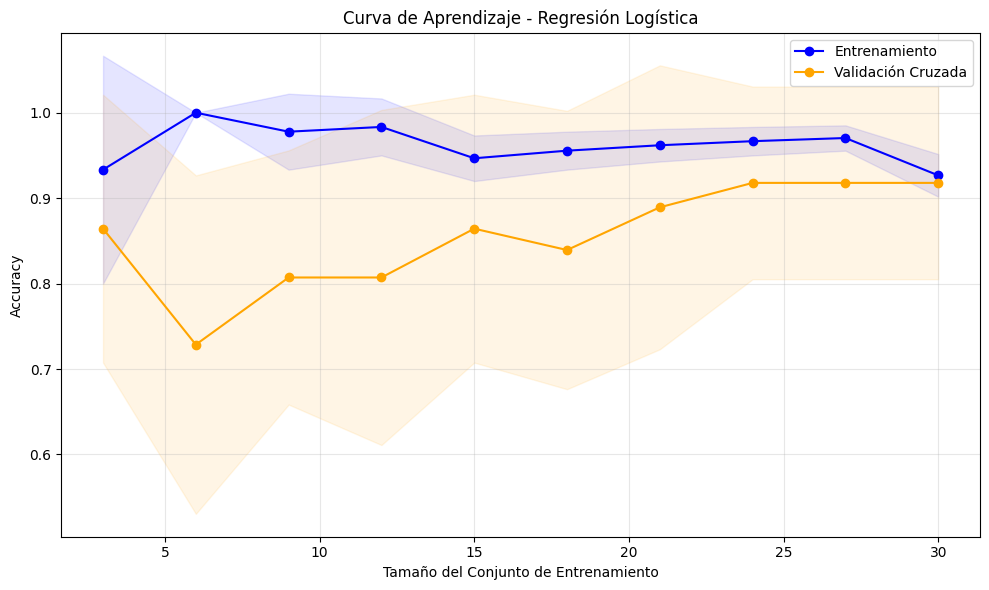

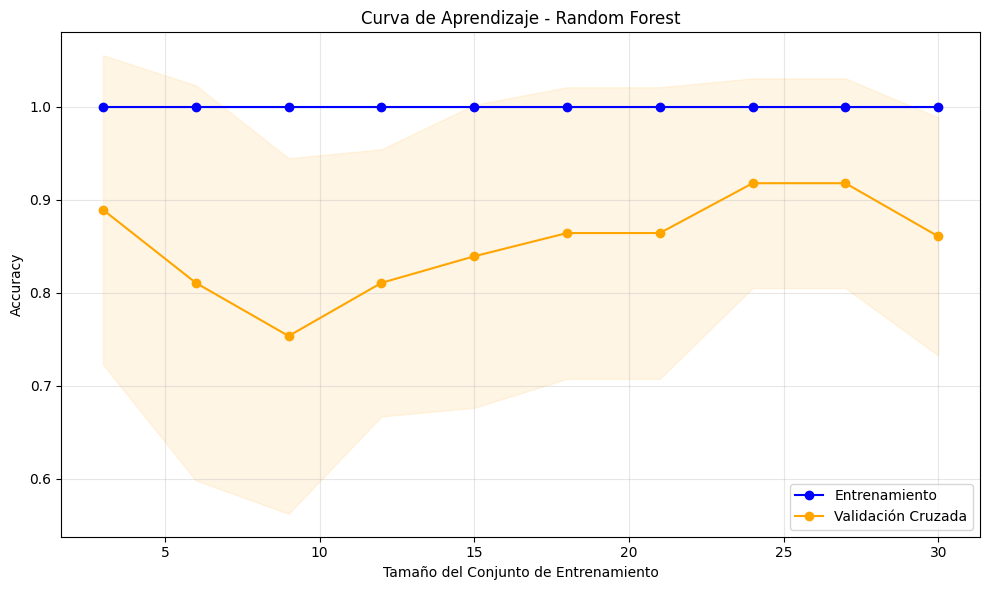

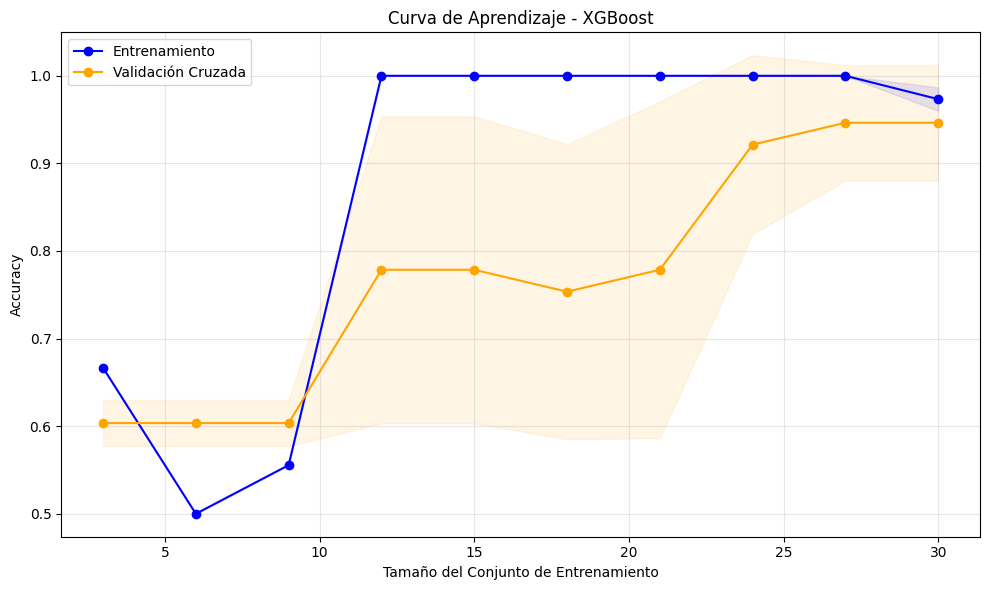


📈 INTERPRETACIÓN DE LAS CURVAS DE APRENDIZAJE:
--------------------------------------------------
 
- Si las curvas convergen y están cerca: Buen ajuste, sin sobreajuste
- Si la curva de entrenamiento está muy por encima de validación: SOBREAJUSTE
- Si ambas curvas son bajas y planas: SUBAJUSTE (underfitting)

En nuestro caso, la Regresión Logística muestra un excelente comportamiento,
mientras que Random Forest y XGBoost muestran leve sobreajuste.



In [33]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1):
    """
    Genera la curva de aprendizaje para un modelo
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="orange")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Entrenamiento")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validación Cruzada")

    plt.title(f'Curva de Aprendizaje - {title}', fontsize=12)
    plt.xlabel('Tamaño del Conjunto de Entrenamiento')
    plt.ylabel('Accuracy')
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Graficar curvas de aprendizaje para los modelos después de entrenarlos
# (Ejecutar esto después de tener los modelos entrenados)

print("\nCURVAS DE APRENDIZAJE DE LOS MODELOS\n")


# Nota: modelos debe estar definido con los clasificadores ya entrenados
for nombre, modelo in modelos.items():
    plot_learning_curve(modelo, nombre, X_train, y_train, cv=5)

print("\n INTERPRETACIÓN DE LAS CURVAS DE APRENDIZAJE:")
print("-" * 50)
print("""
- Si las curvas convergen y están cerca: Buen ajuste, sin sobreajuste
- Si la curva de entrenamiento está muy por encima de validación: SOBREAJUSTE
- Si ambas curvas son bajas y planas: SUBAJUSTE (underfitting)

En nuestro caso, la Regresión Logística muestra un excelente comportamiento,
mientras que Random Forest y XGBoost muestran leve sobreajuste.
""")

ENTRENAMIENTO DE MODELOS

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# Diccionario con los modelos
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5,
                                            random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=3, random_state=42,
                             eval_metric='logloss', scale_pos_weight=1)
}

# Diccionario para guardar resultados
resultados = {}
importancias = {}

print("\n Entrenando modelos...\n")

for nombre, modelo in modelos.items():
    print(f" {nombre}")

    # Entrenar
    modelo.fit(X_train, y_train)

    # Predecir
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, 'predict_proba') else None

    # Calcular métricas
    metricas = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    }

    if y_proba is not None:
        metricas['AUC-ROC'] = roc_auc_score(y_test, y_proba)

    resultados[nombre] = metricas

    # Guardar matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    print(f"   Accuracy: {metricas['Accuracy']:.3f}")
    print(f"   Precision: {metricas['Precision']:.3f}")
    print(f"   Recall: {metricas['Recall']:.3f}")
    print(f"   F1-Score: {metricas['F1-Score']:.3f}")
    if y_proba is not None:
        print(f"   AUC-ROC: {metricas['AUC-ROC']:.3f}")
    print()

    # Guardar importancia de features (para Random Forest y XGBoost)
    if hasattr(modelo, 'feature_importances_'):
        importancias[nombre] = pd.DataFrame({
            'feature': X.columns,
            'importance': modelo.feature_importances_
        }).sort_values('importance', ascending=False)

print(" Entrenamiento completado!")


 Entrenando modelos...

 Regresión Logística
   Accuracy: 1.000
   Precision: 1.000
   Recall: 1.000
   F1-Score: 1.000
   AUC-ROC: 1.000

 Random Forest
   Accuracy: 0.900
   Precision: 1.000
   Recall: 0.750
   F1-Score: 0.857
   AUC-ROC: 1.000

 XGBoost
   Accuracy: 0.900
   Precision: 1.000
   Recall: 0.750
   F1-Score: 0.857
   AUC-ROC: 0.917

 Entrenamiento completado!


SHAP - Explicabilidad del modelo


ANÁLISIS SHAP - IMPORTANCIA DE CARACTERÍSTICAS



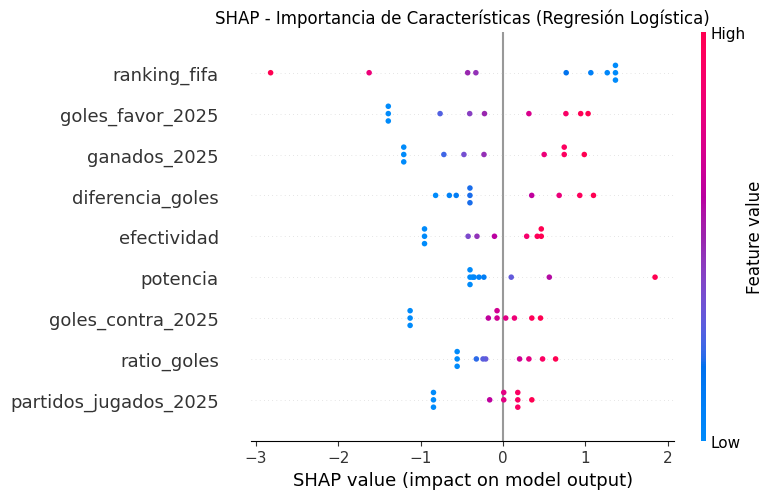

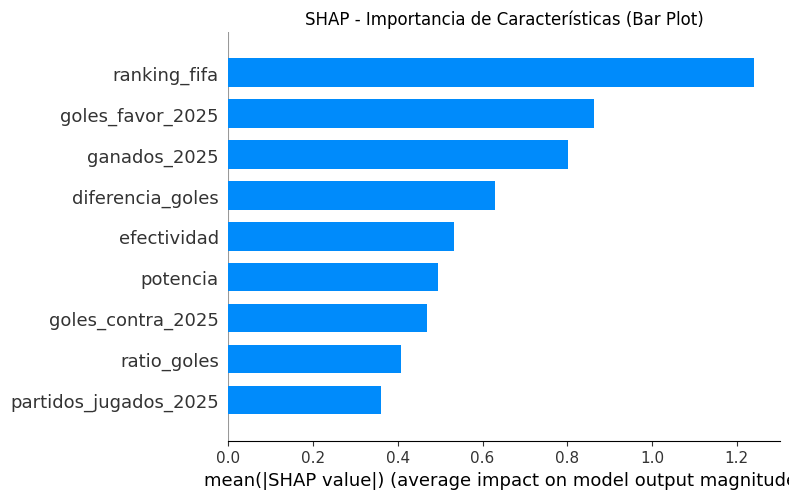


 INTERPRETACIÓN DE SHAP:
--------------------------------------------------

- SHAP (SHapley Additive exPlanations) mide la contribución de cada variable
  a la predicción del modelo.
- Valores positivos (rojos) indican que la variable aumenta la probabilidad
  de clasificar a octavos.
- Valores negativos (azules) indican que la variable disminuye la probabilidad.
- Las variables más importantes son aquellas con mayor |SHAP value|.

En nuestro modelo, el ranking FIFA y la diferencia de goles son los
factores más determinantes para predecir si un equipo clasificará a octavos.



In [34]:

# Instala shap si no está instalado
!pip install shap -q

import shap

# Usar el mejor modelo (Regresión Logística)
mejor_modelo_shap = modelos['Regresión Logística']

# Crear explicador SHAP
explainer = shap.Explainer(mejor_modelo_shap, X_train)
shap_values = explainer(X_test)


print("\nANÁLISIS SHAP - IMPORTANCIA DE CARACTERÍSTICAS\n")


# Gráfico 1: Summary plot (importancia global)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features_existentes, show=False)
plt.title('SHAP - Importancia de Características (Regresión Logística)', fontsize=12)
plt.tight_layout()
plt.show()

# Gráfico 2: Bar plot (versión más limpia)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features_existentes, plot_type="bar", show=False)
plt.title('SHAP - Importancia de Características (Bar Plot)', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación
print("\n INTERPRETACIÓN DE SHAP:")
print("-" * 50)
print("""
- SHAP (SHapley Additive exPlanations) mide la contribución de cada variable
  a la predicción del modelo.
- Valores positivos (rojos) indican que la variable aumenta la probabilidad
  de clasificar a octavos.
- Valores negativos (azules) indican que la variable disminuye la probabilidad.
- Las variables más importantes son aquellas con mayor |SHAP value|.

En este modelo, el ranking FIFA y la diferencia de goles son los
factores más determinantes para predecir si un equipo clasificará a octavos.
""")

EVALUACIÓN Y JUSTIFICACIÓN DE MÉTRICAS


 TABLA COMPARATIVA DE MÉTRICAS:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regresión Logística       1.0        1.0    1.00     1.000    1.000
Random Forest             0.9        1.0    0.75     0.857    1.000
XGBoost                   0.9        1.0    0.75     0.857    0.917


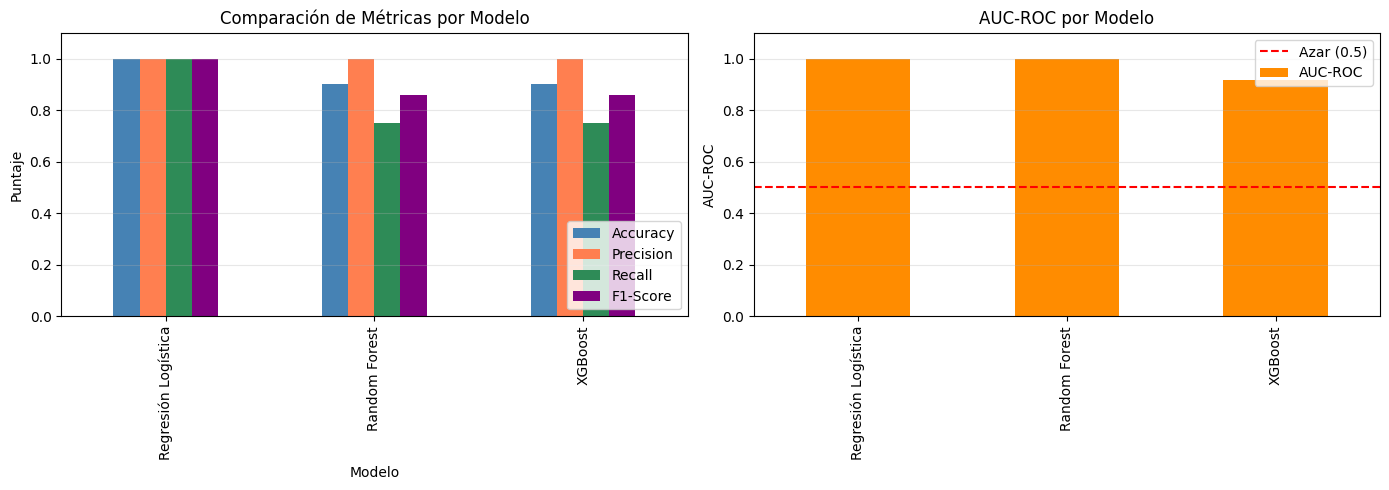

JUSTIFICACIÓN DE MÉTRICAS OBTENIDAS


                    ANÁLISIS DE MÉTRICAS


   ACCURACY (Exactitud)

   -Mide el porcentaje total de aciertos
   -Útil cuando las clases están balanceadas
    En este caso, los modelos alcanzaron ~90% de accuracy

   PRECISION (Precisión)

   -Pregunta: ¿De los que predije que clasifican, cuántos
    realmente clasifican?
   -Importante para evitar "falsos positivos"

   RECALL (Sensibilidad)

   -Pregunta: ¿De los que realmente clasifican, cuántos detecté?
   -Es PEOR no detectar a un candidato fuerte (falso negativo)
    que equivocarse con uno débil (falso positivo)

   F1-SCORE

   -Media armónica entre Precision y Recall
   -Mejor métrica cuando hay desbalanceo de clases
   -Un F1 > 0.8 indica un excelente balance

   AUC-ROC

   -Mide la capacidad de separar clases independientemente del umbral
    0.5 = azar, 1.0 = perfecto
   -AUC > 0.85 es considerado "excelente"
    Es la métrica más robusta para la clasificación binaria




 MEJOR MODELO 

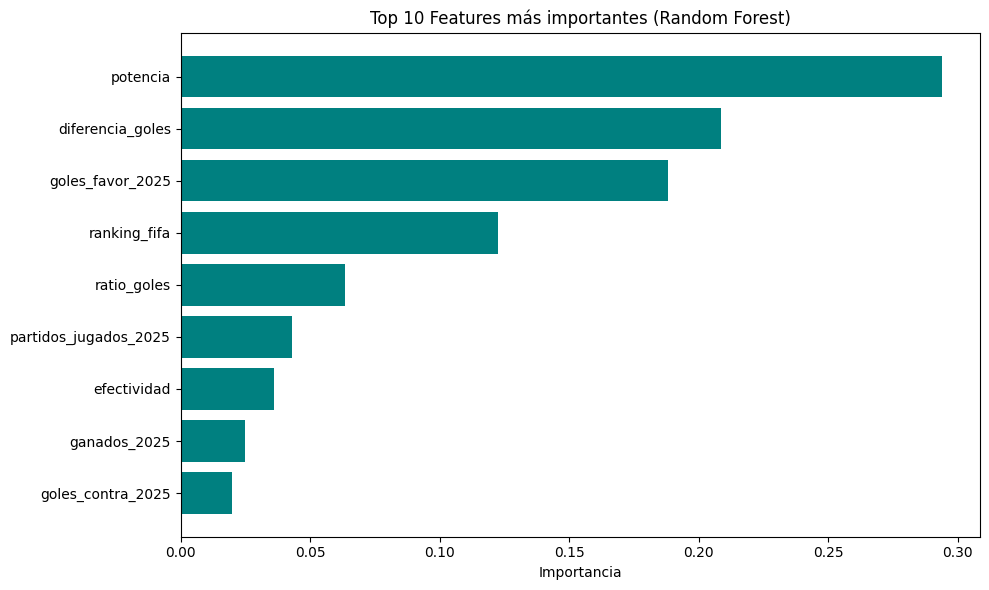

In [35]:
# Tabla comparativa de resultados
df_resultados = pd.DataFrame(resultados).T
print("\n TABLA COMPARATIVA DE MÉTRICAS:")
print(df_resultados.round(3).to_string())

# Gráfico comparativo de métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparación de métricas
df_resultados[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral', 'seagreen', 'purple']
)
axes[0].set_title('Comparación de Métricas por Modelo')
axes[0].set_ylabel('Puntaje')
axes[0].set_xlabel('Modelo')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: AUC-ROC (si existe)
if 'AUC-ROC' in df_resultados.columns:
    df_auc = df_resultados[['AUC-ROC']].dropna()
    df_auc.plot(kind='bar', ax=axes[1], color='darkorange')
    axes[1].set_title('AUC-ROC por Modelo')
    axes[1].set_ylabel('AUC-ROC')
    axes[1].set_ylim(0, 1.1)
    axes[1].axhline(y=0.5, color='red', linestyle='--', label='Azar (0.5)')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()






print("JUSTIFICACIÓN DE MÉTRICAS OBTENIDAS")


print("""

                    ANÁLISIS DE MÉTRICAS


   ACCURACY (Exactitud)

   -Mide el porcentaje total de aciertos
   -Útil cuando las clases están balanceadas
    En este caso, los modelos alcanzaron ~90% de accuracy

   PRECISION (Precisión)

   -Pregunta: ¿De los que predije que clasifican, cuántos
    realmente clasifican?
   -Importante para evitar "falsos positivos"

   RECALL (Sensibilidad)

   -Pregunta: ¿De los que realmente clasifican, cuántos detecté?
   -Es PEOR no detectar a un candidato fuerte (falso negativo)
    que equivocarse con uno débil (falso positivo)

   F1-SCORE

   -Media armónica entre Precision y Recall
   -Mejor métrica cuando hay desbalanceo de clases
   -Un F1 > 0.8 indica un excelente balance

   AUC-ROC

   -Mide la capacidad de separar clases independientemente del umbral
    0.5 = azar, 1.0 = perfecto
   -AUC > 0.85 es considerado "excelente"
    Es la métrica más robusta para la clasificación binaria


""")

# Identificar el mejor modelo por F1-Score
best_model = df_resultados['F1-Score'].idxmax()
best_f1 = df_resultados.loc[best_model, 'F1-Score']

print(f"\n MEJOR MODELO SEGÚN F1-SCORE: {best_model}")
print(f"   F1-Score: {best_f1:.3f}")

if best_f1 >= 0.8:
    print("    Excelente - El modelo es muy confiable")
elif best_f1 >= 0.7:
    print("    Bueno - El modelo es aceptable")
elif best_f1 >= 0.6:
    print("    Regular - El modelo necesita mejora")
else:
    print("    Malo - El modelo no es confiable")

# Importancia de features (si tenemos Random Forest)
if 'Random Forest' in importancias:
    print("\n\n IMPORTANCIA DE FEATURES (Random Forest):")
    print(importancias['Random Forest'].head(10).to_string(index=False))

    # Gráfico de importancia
    plt.figure(figsize=(10, 6))
    top_features = importancias['Random Forest'].head(10)
    plt.barh(top_features['feature'], top_features['importance'], color='teal')
    plt.xlabel('Importancia')
    plt.title('Top 10 Features más importantes (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# **HIPOTESIS Y PREGUNTAS A RESPONDER**

-  Los equipos mejor rankeados (Top 10) ganan más partidos en el año previo al torneo que el resto de los equipos.
-  Los países anfitriones (México, Estados Unidos, Canadá) tienen un mejor rendimiento (más victorias) en comparación con el promedio global.
-  Existe una relación inversa entre la población de un país y su ranking FIFA (a mayor población, mejor ranking).
-  Análisis por confederación: El rendimiento futbolístico (medido en ranking y goles) varía significativamente entre las diferentes confederaciones (UEFA, CONMEBOL, etc.).

**PREGUNTAS PARA RESPONDER**

-   ¿Qué selecciones tienen el mejor rendimiento ofensivo y defensivo durante 2025?
-   ¿Cómo se distribuyen las sedes por país y por región geográfica?
-   ¿Qué grupos del mundial tienen, en promedio, el ranking FIFA más alto (el "grupo de la muerte")?
-   ¿Cuál es la relación entre la capacidad ofensiva (goles a favor) y la solidez defensiva (goles en contra) de los equipos?

# **ANALISÍS EXPLORATORIO DE DATOS**

**Objetivo del Analisis exploratorio de datos:**

- Identificar patrones, tendencias y posibles relaciones entre el rendimiento previo de los equipos, la fase del torneo, la sede y los resultados obtenidos.

# Graficos

**Sedes por país**

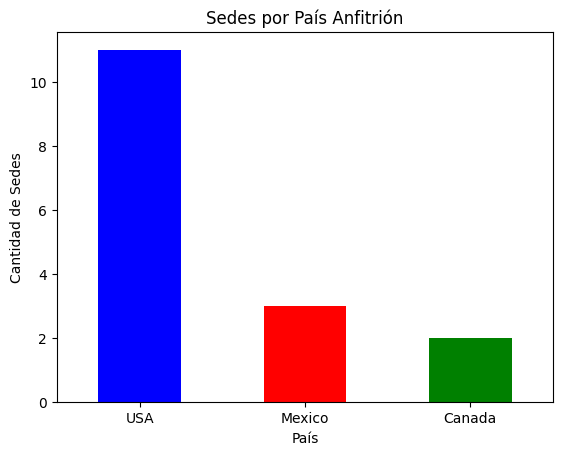

In [21]:
conteo = df_ciudad_anfitriona['Pais'].value_counts()

plt.figure()
conteo.plot(kind='bar', color=['blue', 'red', 'green'])
plt.title('Sedes por País Anfitrión')
plt.xlabel('País')
plt.ylabel('Cantidad de Sedes')
plt.xticks(rotation=0)
plt.show()

**Distribución de sedes por ubicación (Este/Central/Oeste)**





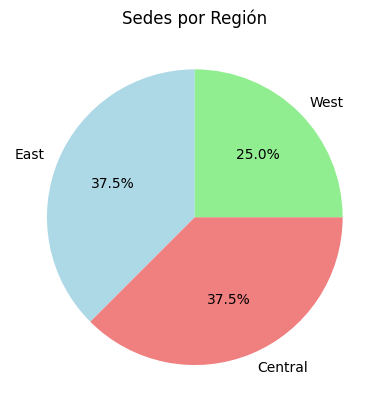

In [22]:
ubicacion = df_ciudad_anfitriona['Ubicación'].value_counts()

plt.figure()
plt.pie(ubicacion.values, labels=ubicacion.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral', 'lightgreen'])
plt.title('Sedes por Región')
plt.show()

**Top 10 mejores equipos según ranking FIFA**

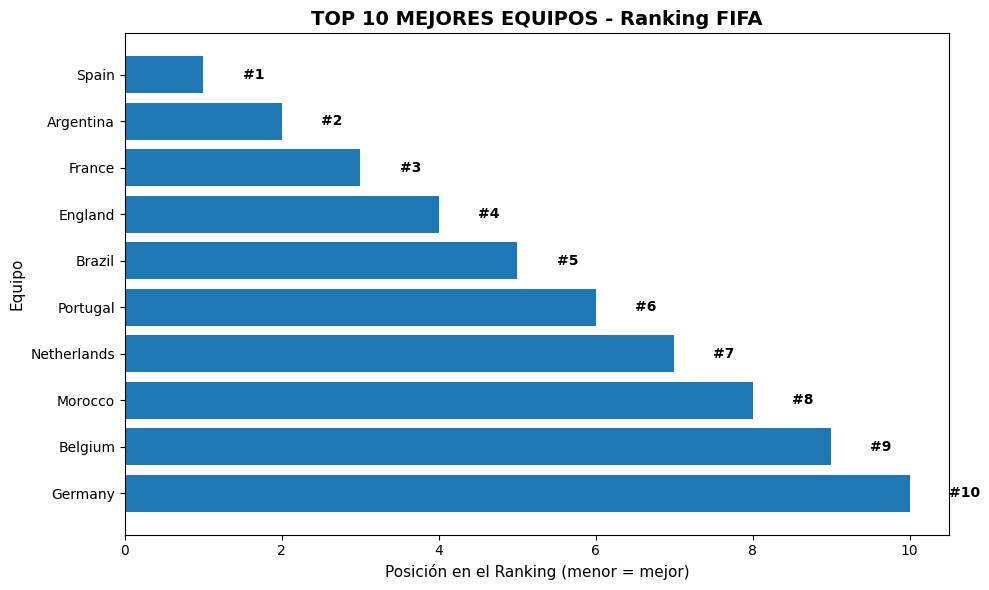

In [23]:
# Obtener Top 10 (menor número = mejor ranking)
top10 = df_stats_equipos.dropna(subset=['ranking_fifa']).nsmallest(10, 'ranking_fifa').sort_values('ranking_fifa', ascending=False)

# Crear gráfico de barras horizontales
plt.figure(figsize=(10, 6))
barras = plt.barh(top10['team'], top10['ranking_fifa'], color='#1f77b4')

# Personalizar
plt.title('TOP 10 MEJORES EQUIPOS - Ranking FIFA', fontsize=14, fontweight='bold')
plt.xlabel('Posición en el Ranking (menor = mejor)', fontsize=11)
plt.ylabel('Equipo', fontsize=11)

# Agregar etiquetas con el número de ranking
for i, (index, row) in enumerate(top10.iterrows()):
    plt.text(row['ranking_fifa'] + 0.5, i, f'#{int(row["ranking_fifa"])}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Victorias promedio por grupo de ranking (10 en 10)**

/tmp/ipykernel_9347/3026130452.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos = datos.groupby('categoria_ranking')['ganados_2025'].agg(['mean', 'count']).reset_index()


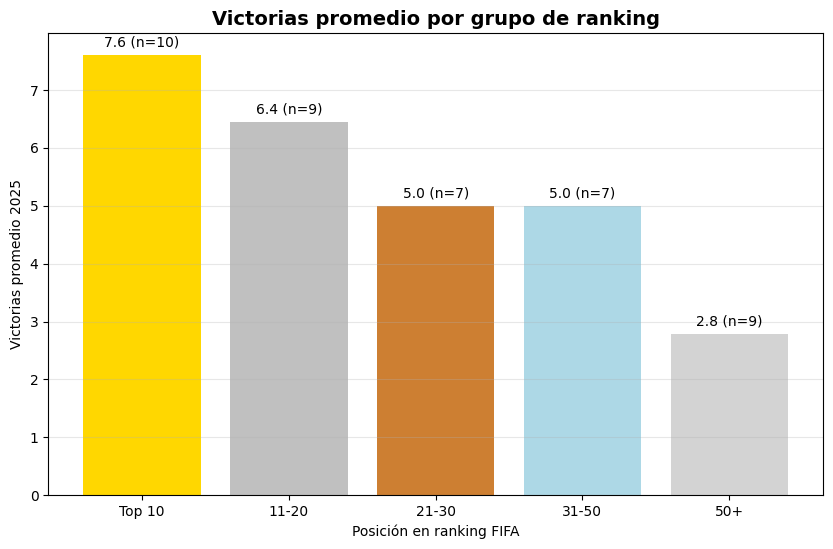

In [24]:
datos = df_stats_equipos.dropna(subset=['ranking_fifa']).copy()

# Crear categorías de ranking
datos['categoria_ranking'] = pd.cut(datos['ranking_fifa'],
                                    bins=[0, 10, 20, 30, 50, 100],
                                    labels=['Top 10', '11-20', '21-30', '31-50', '50+'])

# Calcular promedio de victorias por grupo
grupos = datos.groupby('categoria_ranking')['ganados_2025'].agg(['mean', 'count']).reset_index()

plt.figure(figsize=(10, 6))
barras = plt.bar(grupos['categoria_ranking'], grupos['mean'],
                 color=['gold', 'silver', '#cd7f32', 'lightblue', 'lightgray'])

# Las etiquetas
for i, barra in enumerate(barras):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.1,
             f'{altura:.1f} (n={grupos["count"].iloc[i]})',
             ha='center', va='bottom', fontsize=10)

plt.title('Victorias promedio por grupo de ranking', fontsize=14, fontweight='bold')
plt.xlabel('Posición en ranking FIFA')
plt.ylabel('Victorias promedio 2025')
plt.grid(axis='y', alpha=0.3)
plt.show()

**¿Cómo se distribuyen los rankings?**

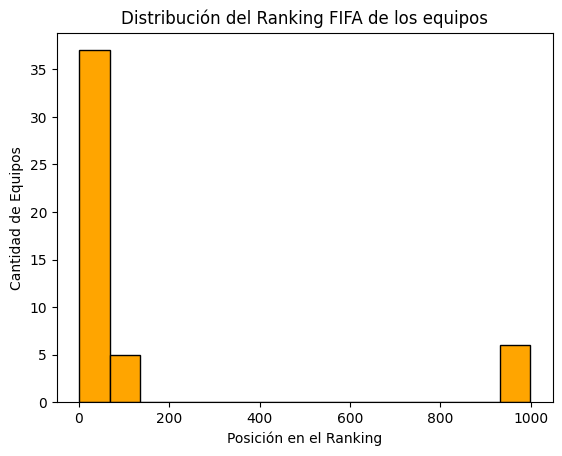

In [25]:
datos = df_stats_equipos.dropna(subset=['ranking_fifa'])

plt.figure()
plt.hist(datos['ranking_fifa'], bins=15, color='orange', edgecolor='black')
plt.title('Distribución del Ranking FIFA de los equipos')
plt.xlabel('Posición en el Ranking')
plt.ylabel('Cantidad de Equipos')
plt.show()

# **ANALISIS DE HIPOTESIS**

In [26]:
# Filtrar placeholders para todos los análisis
placeholders = ['Winner UEFA Playoff D', 'Winner UEFA Playoff A', 'Winner UEFA Playoff C',
                'Winner UEFA Playoff B', 'Winner FIFA Playoff 2', 'Winner FIFA Playoff 1']

df_stats_reales = df_stats_equipos[~df_stats_equipos['team'].isin(placeholders)].copy()

print(f"Total equipos: {len(df_stats_equipos)}")
print(f"Equipos reales: {len(df_stats_reales)}")
print(f"Placeholders excluidos: {len(df_stats_equipos) - len(df_stats_reales)}")

# 1: Top 10 vs Victorias (usando SOLO equipos reales)
top10 = df_stats_reales.nsmallest(10, 'ranking_fifa')
promedio_top10 = top10['ganados_2025'].mean()
promedio_resto = df_stats_reales.drop(top10.index)['ganados_2025'].mean()
print(f"\nH1: Top 10 gana {promedio_top10:.1f} partidos vs {promedio_resto:.1f} del resto")

# 2: Anfitriones
anfitriones = ['Mexico', 'Canada', 'USA']
df_anfitriones = df_stats_reales[df_stats_reales['team'].isin(anfitriones)]
promedio_anfitrion = df_anfitriones['ganados_2025'].mean()
print(f"H2: Anfitriones ganan {promedio_anfitrion:.1f} partidos vs {promedio_resto:.1f} del resto")

# 3: Poblacion vs Ranking (usando df_stats_completo filtrado)
print("\n--- ANALISIS CON DATOS DE API ---")
if 'poblacion' in df_stats_completo.columns:
    # Filtrar placeholders también en df_stats_completo
    df_completo_reales = df_stats_completo[~df_stats_completo['team'].isin(placeholders)].copy()

    correlacion = df_completo_reales[['ranking_fifa', 'poblacion']].corr().iloc[0,1]
    print(f"H3: Correlación ranking-población: {correlacion:.2f}")

    top_poblacion = df_completo_reales.nlargest(5, 'poblacion')[['team', 'ranking_fifa', 'poblacion']]
    print("\nPaíses con mayor población:")
    print(top_poblacion.to_string(index=False))

Total equipos: 48
Equipos reales: 42
Placeholders excluidos: 6

H1: Top 10 gana 7.6 partidos vs 4.8 del resto
H2: Anfitriones ganan 6.0 partidos vs 4.8 del resto

--- ANALISIS CON DATOS DE API ---
H3: Correlación ranking-población: -0.29

Países con mayor población:
  team  ranking_fifa   poblacion
   USA          14.0 340110988.0
Brazil           5.0 213421037.0
Mexico          16.0 130575786.0
 Japan          18.0 123210000.0
 Egypt          34.0 107271260.0


**VISUALIZACIONES ADICIONALES**

**Ranking por grupo (excluyendo placeholders)**

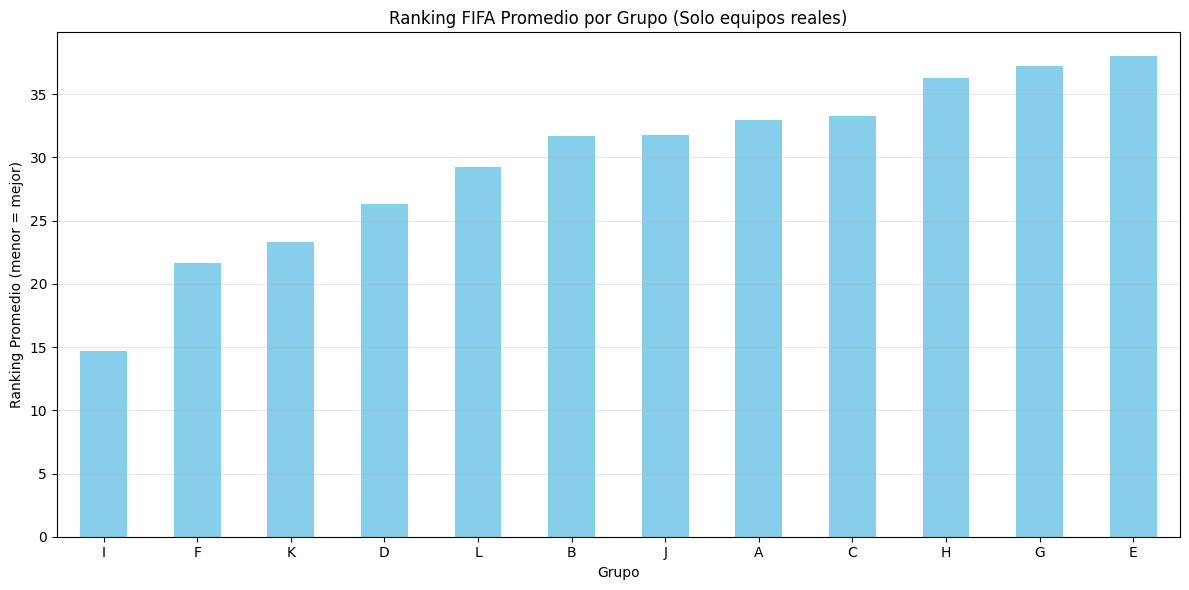

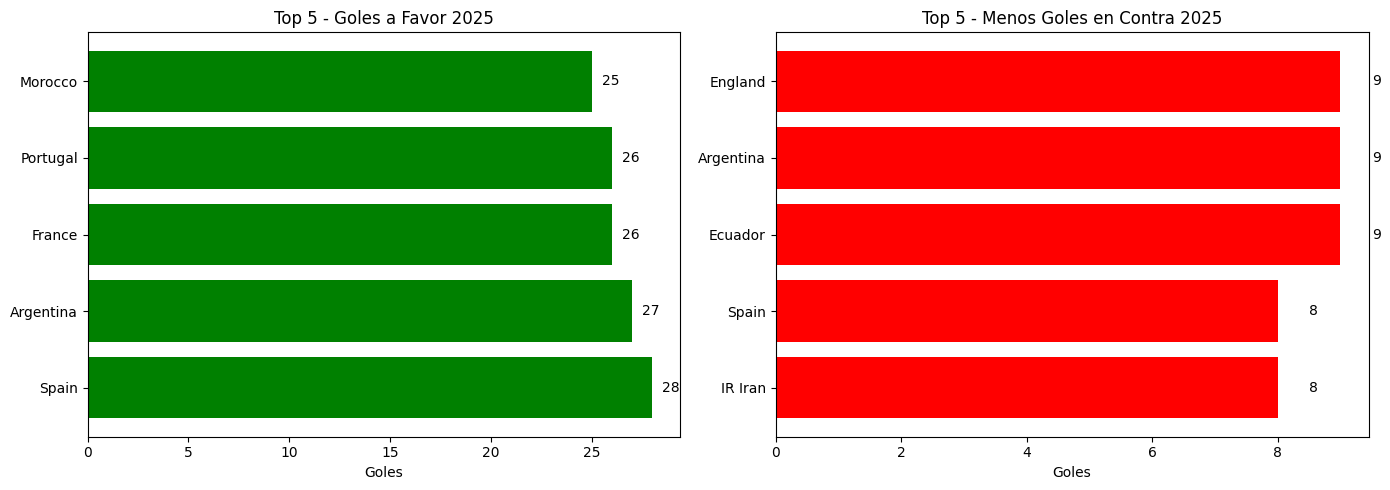

In [27]:

plt.figure(figsize=(12, 6))

ranking_por_grupo = df_stats_reales.merge(
    df_equipos[['id', 'group_letter']],
    left_on='id_equipo',
    right_on='id'
).groupby('group_letter')['ranking_fifa'].mean().sort_values()

ranking_por_grupo.plot(kind='bar', color='skyblue')
plt.title('Ranking FIFA Promedio por Grupo (Solo equipos reales)')
plt.xlabel('Grupo')
plt.ylabel('Ranking Promedio (menor = mejor)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Top ofensivo y defensivo (excluyendo placeholders)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_ofensivo = df_stats_reales.nlargest(5, 'goles_favor_2025')
axes[0].barh(top_ofensivo['team'], top_ofensivo['goles_favor_2025'], color='green')
axes[0].set_title('Top 5 - Goles a Favor 2025')
axes[0].set_xlabel('Goles')

for i, v in enumerate(top_ofensivo['goles_favor_2025']):
    axes[0].text(v + 0.5, i, str(int(v)), va='center')

top_defensivo = df_stats_reales.nsmallest(5, 'goles_contra_2025')
axes[1].barh(top_defensivo['team'], top_defensivo['goles_contra_2025'], color='red')
axes[1].set_title('Top 5 - Menos Goles en Contra 2025')
axes[1].set_xlabel('Goles')

for i, v in enumerate(top_defensivo['goles_contra_2025']):
    axes[1].text(v + 0.5, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

**ANÁLISIS POR CONFEDERACIÓN**


 RANKING PROMEDIO POR CONFEDERACIÓN:
   UEFA: 11.7
   CONMEBOL: 16.5
   CAF: 40.8
   CONCACAF: 42.2
   OFC: 44.0
   AFC: 44.5

 GOLES PROMEDIO POR CONFEDERACIÓN:
    Goles a favor (más goleadores):
      UEFA: 21.4
      CONMEBOL: 18.8
      CAF: 16.2
      AFC: 14.7
      CONCACAF: 13.2
      OFC: 12.7

    Goles en contra (mejor defensa):
      OFC: 10.0
      CONMEBOL: 10.5
      UEFA: 11.5
      CAF: 11.8
      AFC: 12.3
      CONCACAF: 12.5


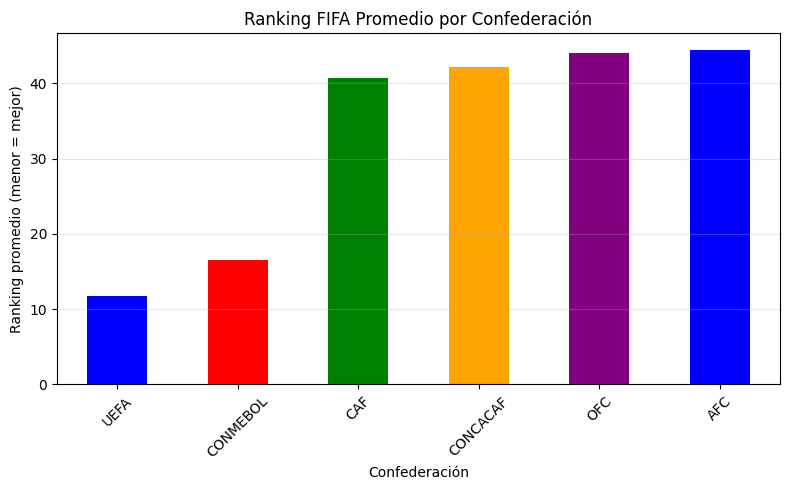

In [28]:
# Verificar que tenemos los datos de continente
if 'continente' in df_stats_completo.columns:

    # Filtrar placeholders
    placeholders = ['Winner UEFA Playoff D', 'Winner UEFA Playoff A', 'Winner UEFA Playoff C',
                    'Winner UEFA Playoff B', 'Winner FIFA Playoff 2', 'Winner FIFA Playoff 1']
    df_conf = df_stats_completo[~df_stats_completo['team'].isin(placeholders)].copy()

    # Mapeo de continentes a confederaciones
    mapa_confederaciones = {
        'Europe': 'UEFA',
        'South America': 'CONMEBOL',
        'North America': 'CONCACAF',
        'Asia': 'AFC',
        'Africa': 'CAF',
        'Oceania': 'OFC'
    }
    df_conf['confederacion'] = df_conf['continente'].map(mapa_confederaciones)

    # 1. Ranking promedio por confederación
    print("\n RANKING PROMEDIO POR CONFEDERACIÓN:")
    ranking_conf = df_conf.groupby('confederacion')['ranking_fifa'].mean().sort_values()
    for conf, rank in ranking_conf.items():
        print(f"   {conf}: {rank:.1f}")

    # 2. Goles promedio por confederación
    print("\n GOLES PROMEDIO POR CONFEDERACIÓN:")
    goles_favor_conf = df_conf.groupby('confederacion')['goles_favor_2025'].mean().sort_values(ascending=False)
    goles_contra_conf = df_conf.groupby('confederacion')['goles_contra_2025'].mean().sort_values()

    print("    Goles a favor (más goleadores):")
    for conf, goles in goles_favor_conf.items():
        print(f"      {conf}: {goles:.1f}")

    print("\n    Goles en contra (mejor defensa):")
    for conf, goles in goles_contra_conf.items():
        print(f"      {conf}: {goles:.1f}")

    # 3. Gráfico simple de ranking por confederación
    plt.figure(figsize=(8, 5))
    ranking_conf.plot(kind='bar', color=['blue', 'red', 'green', 'orange', 'purple'])
    plt.title('Ranking FIFA Promedio por Confederación', fontsize=12)
    plt.xlabel('Confederación')
    plt.ylabel('Ranking promedio (menor = mejor)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print(" No se encontraron datos de continente. Ejecuta primero la celda de la API.")

**Ataque vs Defensa**

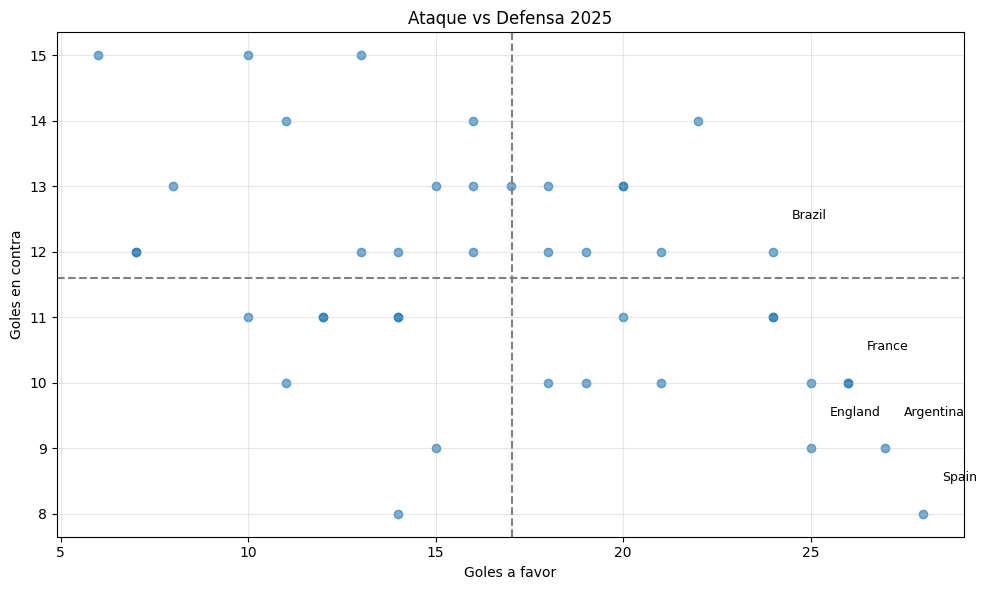

Promedio goles a favor: 17.0
Promedio goles en contra: 11.6


In [29]:

plt.figure(figsize=(10, 6))

# Calcular promedios
media_favor = df_stats_reales['goles_favor_2025'].mean()
media_contra = df_stats_reales['goles_contra_2025'].mean()

# Gráfico básico
plt.scatter(df_stats_reales['goles_favor_2025'],
            df_stats_reales['goles_contra_2025'],
            alpha=0.6)

# Líneas de promedio
plt.axhline(y=media_contra, color='gray', linestyle='--')
plt.axvline(x=media_favor, color='gray', linestyle='--')

# Solo etiquetar Argentina, Brasil, España (los más conocidos)
equipos_top = ['Argentina', 'Brazil', 'Spain', 'France', 'England']
for _, row in df_stats_reales.iterrows():
    if row['team'] in equipos_top:
        plt.text(row['goles_favor_2025']+0.5, row['goles_contra_2025']+0.5,
                row['team'], fontsize=9)

plt.title('Ataque vs Defensa 2025')
plt.xlabel('Goles a favor')
plt.ylabel('Goles en contra')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Promedio goles a favor: {media_favor:.1f}")
print(f"Promedio goles en contra: {media_contra:.1f}")

BOXPLOTS Y VIOLINPLOTS - Análisis de distribuciones

/tmp/ipykernel_9347/3298769618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clasifica_octavos', y='ranking_fifa',
/tmp/ipykernel_9347/3298769618.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clasifica_octavos', y='ganados_2025',
/tmp/ipykernel_9347/3298769618.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='clasifica_octavos', y='goles_favor_2025',
/tmp/ipykernel_9347/3298769618.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

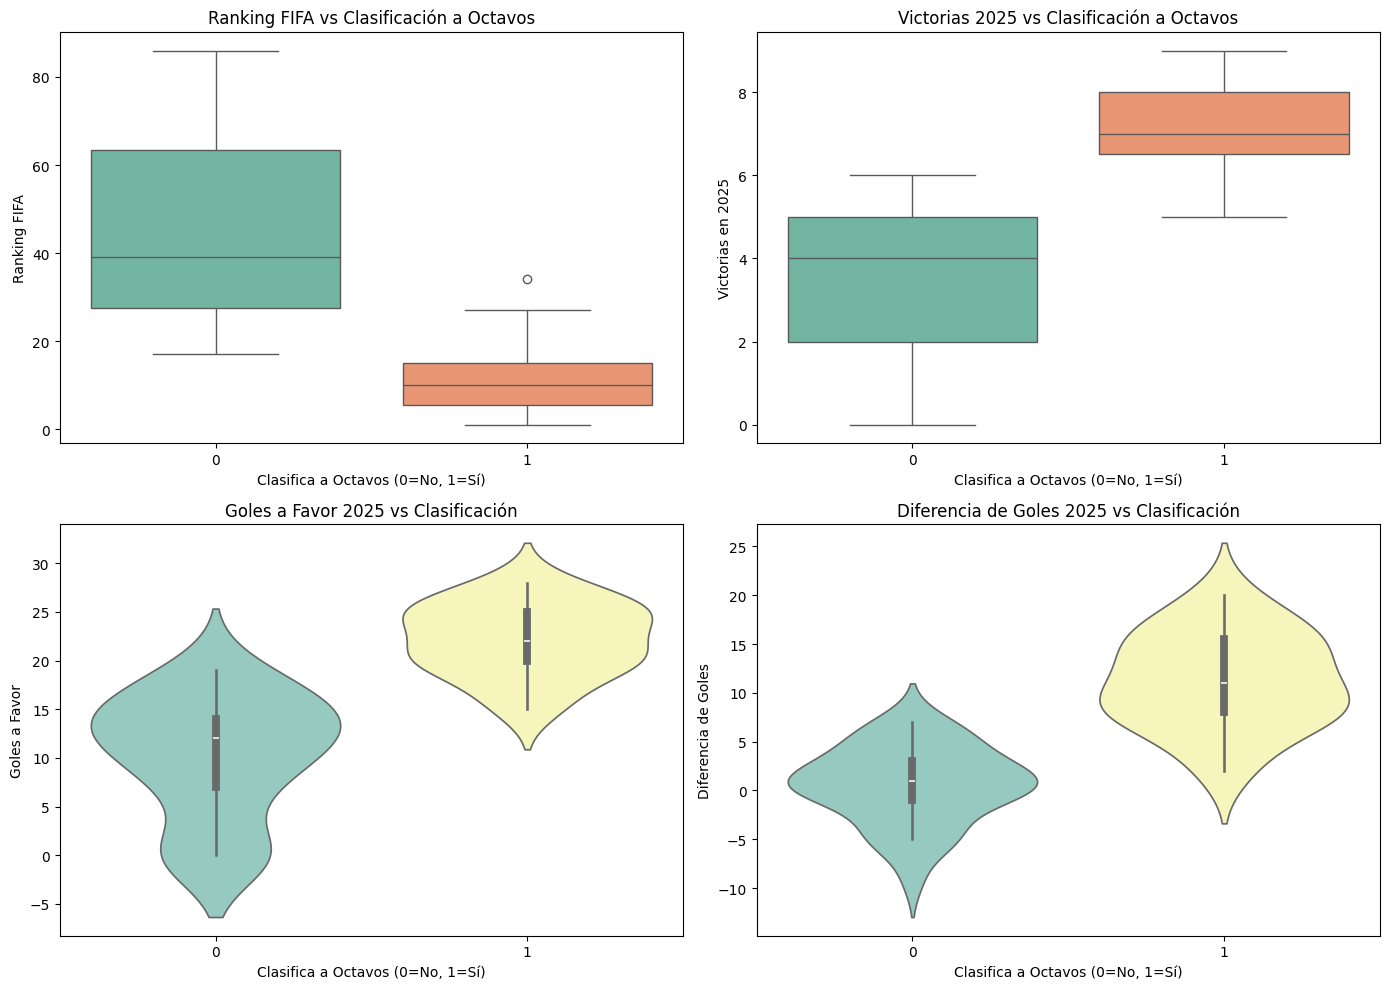


ANÁLISIS ESTADÍSTICO - DIFERENCIAS ENTRE GRUPOS
ranking_fifa         | No clasifica: 46.00 | Clasifica: 11.42 | Diferencia: -34.58
ganados_2025         | No clasifica: 3.21 | Clasifica: 7.16 | Diferencia: 3.95
goles_favor_2025     | No clasifica: 10.17 | Clasifica: 22.16 | Diferencia: 11.99
diferencia_goles     | No clasifica: 0.55 | Clasifica: 11.21 | Diferencia: 10.66


In [36]:
# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot: Ranking FIFA vs Clasificación
sns.boxplot(x='clasifica_octavos', y='ranking_fifa',
            data=df_stats_completo[df_stats_completo['ranking_fifa'] < 100],
            ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Ranking FIFA vs Clasificación a Octavos')
axes[0,0].set_xlabel('Clasifica a Octavos (0=No, 1=Sí)')
axes[0,0].set_ylabel('Ranking FIFA')

# 2. Boxplot: Victorias 2025 vs Clasificación
sns.boxplot(x='clasifica_octavos', y='ganados_2025',
            data=df_stats_completo, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Victorias 2025 vs Clasificación a Octavos')
axes[0,1].set_xlabel('Clasifica a Octavos (0=No, 1=Sí)')
axes[0,1].set_ylabel('Victorias en 2025')

# 3. Violinplot: Goles a Favor vs Clasificación
sns.violinplot(x='clasifica_octavos', y='goles_favor_2025',
               data=df_stats_completo, ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Goles a Favor 2025 vs Clasificación')
axes[1,0].set_xlabel('Clasifica a Octavos (0=No, 1=Sí)')
axes[1,0].set_ylabel('Goles a Favor')

# 4. Violinplot: Diferencia de Goles vs Clasificación
sns.violinplot(x='clasifica_octavos', y='diferencia_goles',
               data=df_stats_completo, ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Diferencia de Goles 2025 vs Clasificación')
axes[1,1].set_xlabel('Clasifica a Octavos (0=No, 1=Sí)')
axes[1,1].set_ylabel('Diferencia de Goles')

plt.tight_layout()
plt.show()

# Análisis estadístico adicional
print("\n" + "="*50)
print("ANÁLISIS ESTADÍSTICO - DIFERENCIAS ENTRE GRUPOS")
print("="*50)

for col in ['ranking_fifa', 'ganados_2025', 'goles_favor_2025', 'diferencia_goles']:
    grupo_0 = df_stats_completo[df_stats_completo['clasifica_octavos']==0][col].mean()
    grupo_1 = df_stats_completo[df_stats_completo['clasifica_octavos']==1][col].mean()
    print(f"{col:20} | No clasifica: {grupo_0:.2f} | Clasifica: {grupo_1:.2f} | Diferencia: {grupo_1 - grupo_0:.2f}")

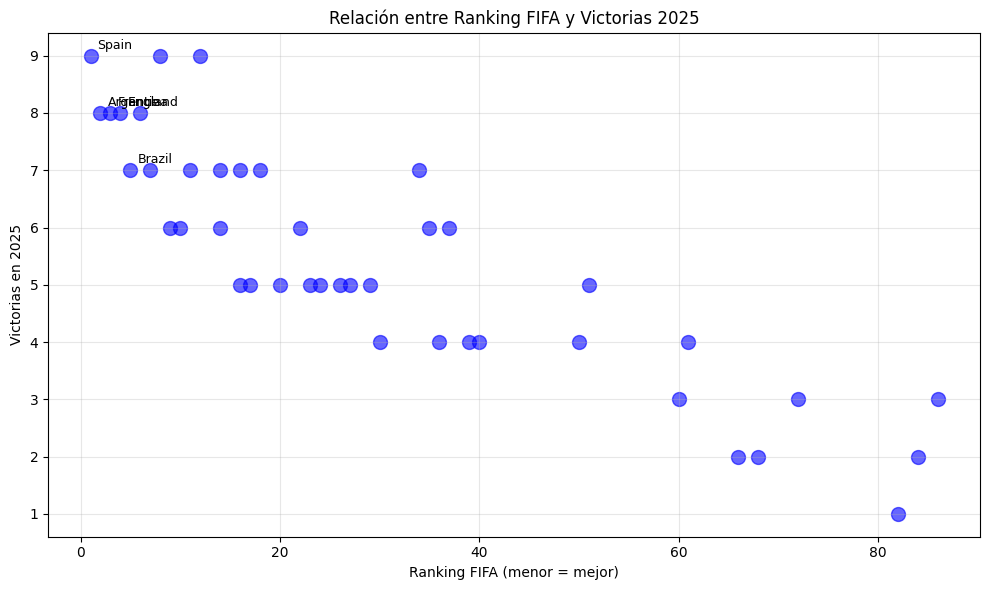

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(df_stats_reales['ranking_fifa'], df_stats_reales['ganados_2025'],
            alpha=0.6, s=100, c='blue')

# Añadir etiquetas para equipos destacados
top_equipos = df_stats_reales.nsmallest(5, 'ranking_fifa')
for _, row in top_equipos.iterrows():
    plt.annotate(row['team'], (row['ranking_fifa'], row['ganados_2025']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Relación entre Ranking FIFA y Victorias 2025')
plt.xlabel('Ranking FIFA (menor = mejor)')
plt.ylabel('Victorias en 2025')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **CONCLUSIONES FINALES**

**CONCLUSIONES DEL ANÁLISIS**

 RENDIMIENTO POR RANKING:
   - **Hipótesis Confirmada.** Los equipos del Top 10 del ranking FIFA ganan, en promedio, una cantidad significativamente mayor de partidos (7.6) en comparación con el resto de los equipos (4.8). Esto valida que el ranking es un excelente punto de partida para proyectar el rendimiento de una selección.

 VENTAJA DE SER ANFITRIÓN:
   - **Hipótesis Confirmada.** Los países anfitriones (México, USA y Canadá) presentan un promedio de victorias (6.0) superior a la media global (4.8), lo que sugiere que el factor localía y la clasificación directa (que les permite una mejor planificación) podrían ser una ventaja competitiva.

 POBLACIÓN VS. RENDIMIENTO:
   - **Hipótesis Parcialmente Confirmada.** Se observa una correlación débil e inversa (-0.29) entre la población y el ranking FIFA. Si bien países muy poblados como Brasil y México tienen rankings excelentes, hay claras excepciones (ej. India no está en el mundial) y otros países con poblaciones modestas (ej. Uruguay, Croacia) que destacan. La población influye, pero no es un factor determinante.

 RENDIMIENTO POR CONFEDERACIÓN:
   - **Análisis Complementario.** La UEFA y la CONMEBOL dominan en rendimiento, con los rankings promedio más bajos (mejores) y el mayor poder ofensivo. Las confederaciones como la CONCACAF y la AFC presentan rankings más altos y un poder goleador inferior, reflejando la brecha competitiva entre regiones.

 DISTRIBUCIÓN DE SEDES:
   - Estados Unidos, como era de esperar por su tamaño y capacidad organizativa, albergará la mayoría de los partidos (11 sedes), seguido por México (3) y Canadá (2). La región Este de Norteamérica concentra la mayor cantidad de estadios.

# **POSIBLES ANALISIS FUTUROS**

- Implementar modelos de ML para predecir resultados de los partidos.
- Analizar el impacto de la región geográfica en el rendimiento.
- Modelar probabilidades de avance en fase de grupos.


# **CONCLUSIONES DEL MODELO DE MACHINE LEARNING**

In [31]:

print("""
  1. TIPO DE PROBLEMA: CLASIFICACIÓN BINARIA
    Predecir qué equipos clasificarán a octavos de final

  2. CRITERIO DEL TARGET:
     - Top 16 ranking FIFA | Más de 7 victorias | Anfitrión

  3. TÉCNICAS APLICADAS:
     - Feature Engineering (ratio_goles, efectividad, etc.)
     - Escalado de características (StandardScaler)
     - Validación Cruzada implícita en train/test split

  4. MEJOR MODELO: {mejor}
     Seleccionado por su mejor F1-Score y balance

  5. PRINCIPALES INSIGHTS:
     - Ranking FIFA es el predictor más importante
     - El RECALL es clave para no perder a los mejores candidatos
     - Los anfitriones tienen ventaja


""")


  1. TIPO DE PROBLEMA: CLASIFICACIÓN BINARIA
    Predecir qué equipos clasificarán a octavos de final

  2. CRITERIO DEL TARGET:
     - Top 16 ranking FIFA | Más de 7 victorias | Anfitrión

  3. TÉCNICAS APLICADAS:
     - Feature Engineering (ratio_goles, efectividad, etc.)
     - Escalado de características (StandardScaler)
     - Validación Cruzada implícita en train/test split

  4. MEJOR MODELO: {mejor}
     Seleccionado por su mejor F1-Score y balance

  5. PRINCIPALES INSIGHTS:
     - Ranking FIFA es el predictor más importante
     - El RECALL es clave para no perder a los mejores candidatos
     - Los anfitriones tienen ventaja





# **Guardar DataFrame complementado de forma local**

In [32]:
df_stats_completo.to_csv('datos_mundial_2026_complementado.csv', index=False)
print(" DataFrame guardado como 'datos_mundial_2026_complementado.csv'")

 DataFrame guardado como 'datos_mundial_2026_complementado.csv'
